# Understanding Underfitting and Overfitting

## Theory

### What is Underfitting?
- Model is too simple to capture the underlying pattern in the data
- High bias, low variance
- Poor performance on both training and test data
- Example: Using a linear model for non-linear data

### What is Overfitting?
- Model is too complex and captures noise in the training data
- Low bias, high variance
- Excellent performance on training data but poor on test data
- Example: Using a high-degree polynomial for simple data

### Just Right (Good Fit)
- Model complexity matches the true underlying pattern
- Good balance between bias and variance
- Good performance on both training and test data

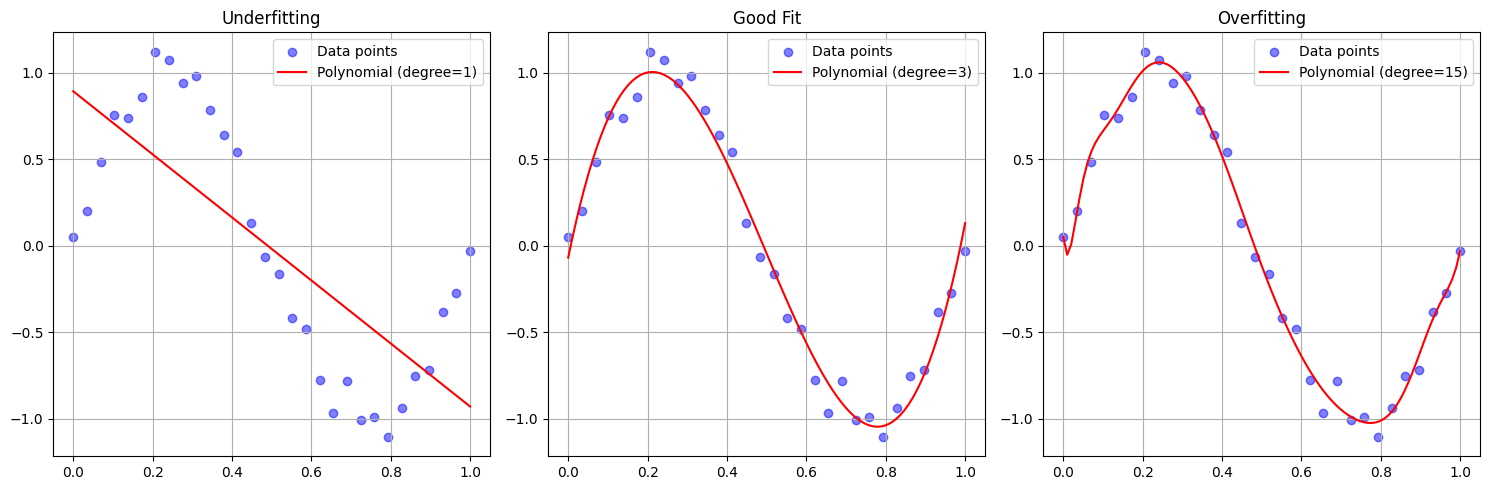

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data
X = np.linspace(0, 1, 30).reshape(-1, 1)
y = np.sin(2 * np.pi * X) + np.random.normal(0, 0.1, X.shape)

# Create models with different complexities
degrees = [1, 3, 15]  # Underfitting, Good fit, Overfitting
plt.figure(figsize=(15, 5))

for i, degree in enumerate(degrees):
    plt.subplot(1, 3, i + 1)
    
    # Create and fit the model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)
    
    # Generate points for smooth curve
    X_test = np.linspace(0, 1, 100).reshape(-1, 1)
    y_pred = model.predict(X_test)
    
    # Plot
    plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')
    plt.plot(X_test, y_pred, color='red', label=f'Polynomial (degree={degree})')
    plt.title(['Underfitting', 'Good Fit', 'Overfitting'][i])
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Learning Curves

Learning curves help us visualize how model performance changes with increasing training data. They are excellent tools for diagnosing underfitting and overfitting.

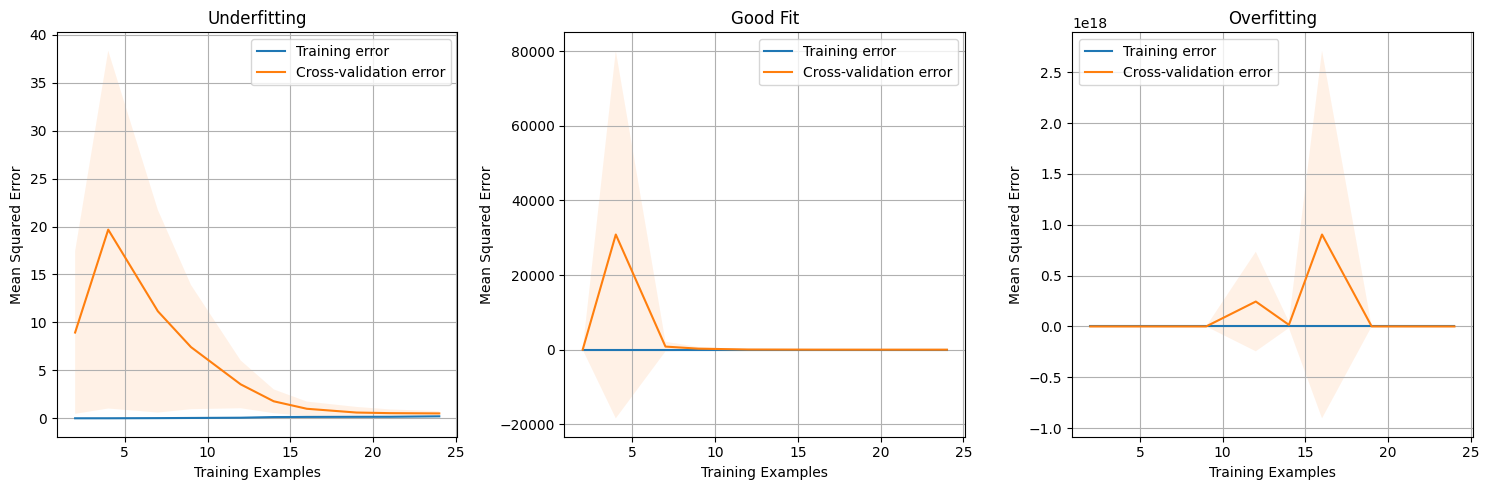

In [2]:
from sklearn.model_selection import learning_curve

def plot_learning_curves(degrees):
    plt.figure(figsize=(15, 5))
    
    for i, degree in enumerate(degrees):
        plt.subplot(1, 3, i + 1)
        
        # Create model
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        
        # Calculate learning curves
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y.ravel(),
            train_sizes=np.linspace(0.1, 1.0, 10),
            cv=5,
            scoring='neg_mean_squared_error'
        )
        
        # Calculate mean and std
        train_mean = -np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = -np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)
        
        # Plot learning curves
        plt.plot(train_sizes, train_mean, label='Training error')
        plt.plot(train_sizes, test_mean, label='Cross-validation error')
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1)
        
        plt.title(['Underfitting', 'Good Fit', 'Overfitting'][i])
        plt.xlabel('Training Examples')
        plt.ylabel('Mean Squared Error')
        plt.legend(loc='best')
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_learning_curves([1, 3, 15])

## Interpreting the Results

### Underfitting (Degree 1)
- Linear model can't capture the sinusoidal pattern
- High error on both training and test sets
- Learning curves show high bias (both curves are high and close together)

### Good Fit (Degree 3)
- Model captures the main pattern without fitting the noise
- Reasonable error on both training and test sets
- Learning curves show good balance between bias and variance

### Overfitting (Degree 15)
- Model fits the noise in the training data
- Very low training error but high test error
- Learning curves show high variance (large gap between training and test error)

## Solutions

### For Underfitting:
1. Increase model complexity
2. Add more features
3. Reduce regularization

### For Overfitting:
1. Collect more training data
2. Reduce model complexity
3. Add regularization
4. Use cross-validation
5. Feature selection/reduction